# Fixed-Point Cast Roundtrip Error

Benchmark the quantization error introduced by `float_to_fixed` → `fixed_to_float` roundtrip.

For each floating-point type (fp16, fp32, fp64), we cast to every `intN` where `N >= float bit-width`, then cast back and measure **relative error**.

`frac_bits` is chosen per (float, int) pair to maximise precision while keeping the fixed-point range ≥ the float's max normal value. Test values are generated by sampling random mantissas for every normal exponent.

In [31]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath("../../tests/triton_kernels"))

import numpy as np
import torch
import matplotlib.pyplot as plt
from fixed_point_helpers import f2x, x2f

In [ ]:
import math

FLOAT_INFO = {
    torch.float16:  {"exp_range": (-14, 15),     "label": "fp16", "max_exp": 16},
    torch.float32:  {"exp_range": (-126, 127),   "label": "fp32", "max_exp": 128},
    torch.float64:  {"exp_range": (-1022, 1023), "label": "fp64", "max_exp": 1024},
}


def frac_bits_for(float_dtype, int_bits):
    """Max frac_bits so that the fixed-point range covers the float's max normal value.

    Range = 2^(int_bits - 1 - frac_bits)  >=  2^max_exp
    =>  frac_bits  <=  int_bits - 1 - max_exp
    """
    max_exp = FLOAT_INFO[float_dtype]["max_exp"]
    return max(int_bits - 1 - max_exp, 0)


def sample_by_exponent(float_dtype, n_per_exp=32, seed=42):
    """Generate positive floats by sampling random mantissas per exponent."""
    info = FLOAT_INFO[float_dtype]
    min_exp, max_exp = info["exp_range"]
    rng = np.random.default_rng(seed)

    exponents = np.arange(min_exp, max_exp + 1)
    mantissa = rng.random((len(exponents), n_per_exp))       # uniform in [0, 1)
    values = np.ldexp(1.0 + mantissa, exponents[:, None])    # 2^e * (1+m)

    np_dtype = torch.zeros(1, dtype=float_dtype).numpy().dtype
    return torch.from_numpy(values.ravel().astype(np_dtype)).cuda()


def roundtrip_error(values, float_dtype, int_dtype, frac_bits, chunk=16384):
    """Cast fp -> fx -> fp in chunks and return (rel_error, values) as numpy."""
    all_err = []
    for i in range(0, len(values), chunk):
        v = values[i : i + chunk]
        recovered = x2f(f2x(v, frac_bits, int_dtype), frac_bits, float_dtype)
        all_err.append((recovered - v).abs() / v.abs())
    rel_err = torch.cat(all_err).cpu().float().numpy()
    vals = values.cpu().float().numpy()
    return rel_err, vals

In [ ]:
INT_BITS = {torch.int16: 16, torch.int32: 32, torch.int64: 64}
BITWIDTH_COLORS = {16: "#e41a1c", 32: "#377eb8", 64: "#4daf4a"}


def plot_cast_error(float_dtype, int_dtypes):
    """Plot roundtrip relative error for one float type across multiple int types."""
    info = FLOAT_INFO[float_dtype]
    values = sample_by_exponent(float_dtype)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xscale("log")
    ax.set_yscale("log")

    # ── Pass 1: plot only nonzero errors to establish y-limits ───────
    cached = []  # (int_bits, vals_exact, zorder)
    has_exact = False
    for zorder, int_dtype in enumerate(reversed(int_dtypes)):
        int_bits = INT_BITS[int_dtype]
        frac = frac_bits_for(float_dtype, int_bits)
        int_part = int_bits - 1 - frac
        label = f"int{int_bits}  (Q{int_part}.{frac})"

        rel_err, vals = roundtrip_error(values, float_dtype, int_dtype, frac)
        nonzero = rel_err > 0
        exact = ~nonzero

        if nonzero.any():
            ax.scatter(vals[nonzero], rel_err[nonzero], s=4, alpha=0.5,
                       label=label, color=BITWIDTH_COLORS[int_bits],
                       zorder=2 + zorder)

        if exact.any():
            has_exact = True
            cached.append((int_bits, vals[exact], zorder,
                           label if not nonzero.any() else None))

    # ── Pass 2: place exact (zero-error) points on a sentinel row ────
    if has_exact:
        sentinel = ax.get_ylim()[0] * 0.1  # one decade below lowest real error

        for int_bits, vals_exact, zorder, label in cached:
            ax.scatter(vals_exact, np.full(len(vals_exact), sentinel),
                       s=4, alpha=0.5, color=BITWIDTH_COLORS[int_bits],
                       label=label,  # only set if this type had *no* nonzero errors
                       zorder=2 + zorder)

        ax.set_ylim(bottom=sentinel * 0.3)
        ax.axhline(sentinel, color="grey", linewidth=0.5, linestyle=":", zorder=1)
        ax.annotate("exact (zero error)", xy=(ax.get_xlim()[0], sentinel),
                    fontsize=8, color="grey", va="bottom", ha="left",
                    xytext=(5, 2), textcoords="offset points")

    ax.set_xlabel(f"{info['label']} value")
    ax.set_ylabel("Relative error  |roundtrip − original| / |original|")
    ax.set_title(f"Fixed-point roundtrip error:  {info['label']}  →  intN  →  {info['label']}")
    ax.legend(markerscale=4)
    ax.grid(True, which="both", alpha=0.2)
    plt.tight_layout()
    plt.show()

## fp16 → int{16, 32, 64} → fp16

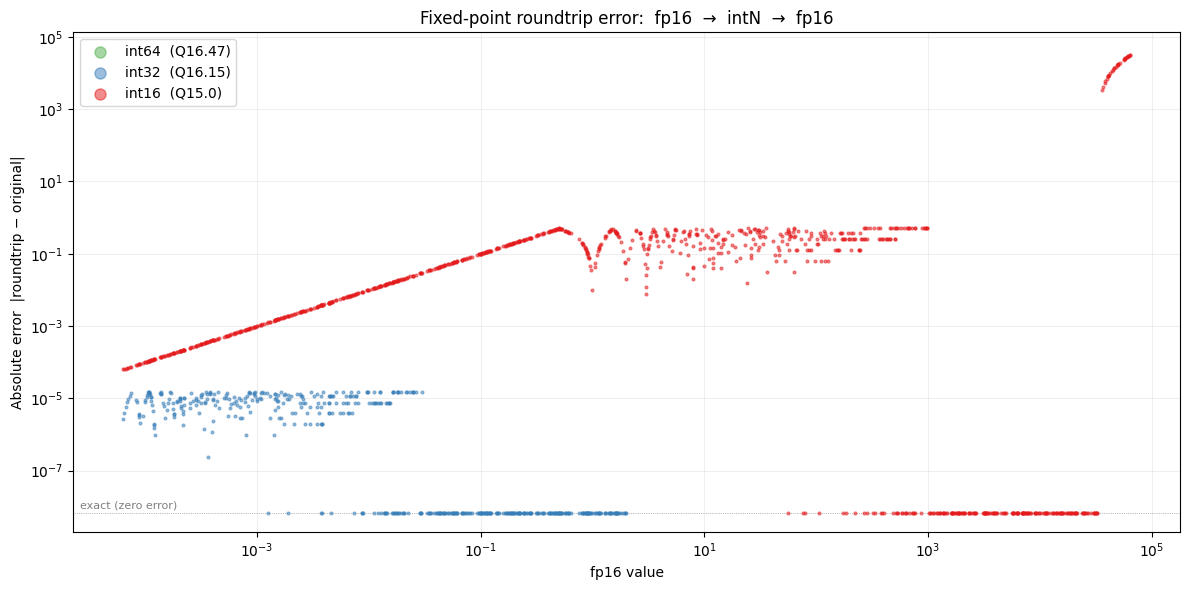

In [ ]:
#TODO: fix fp64 not showing in plot
plot_cast_error(torch.float16, [torch.int16, torch.int32, torch.int64])

## fp32 → int{32, 64} → fp32

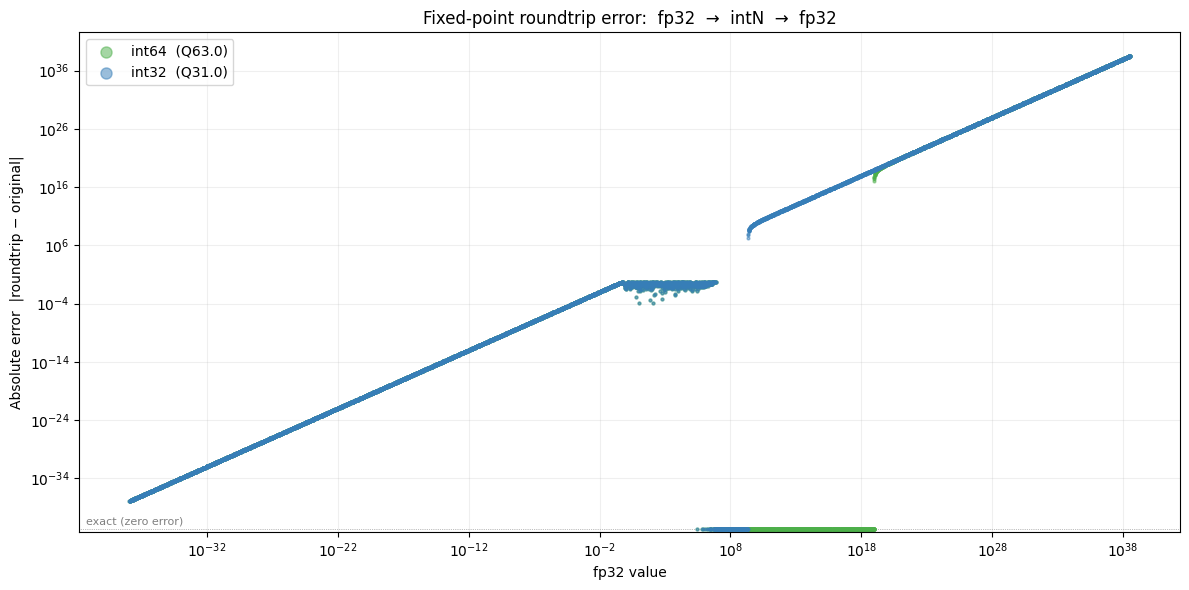

In [35]:
plot_cast_error(torch.float32, [torch.int32, torch.int64])

## fp64 → int64 → fp64

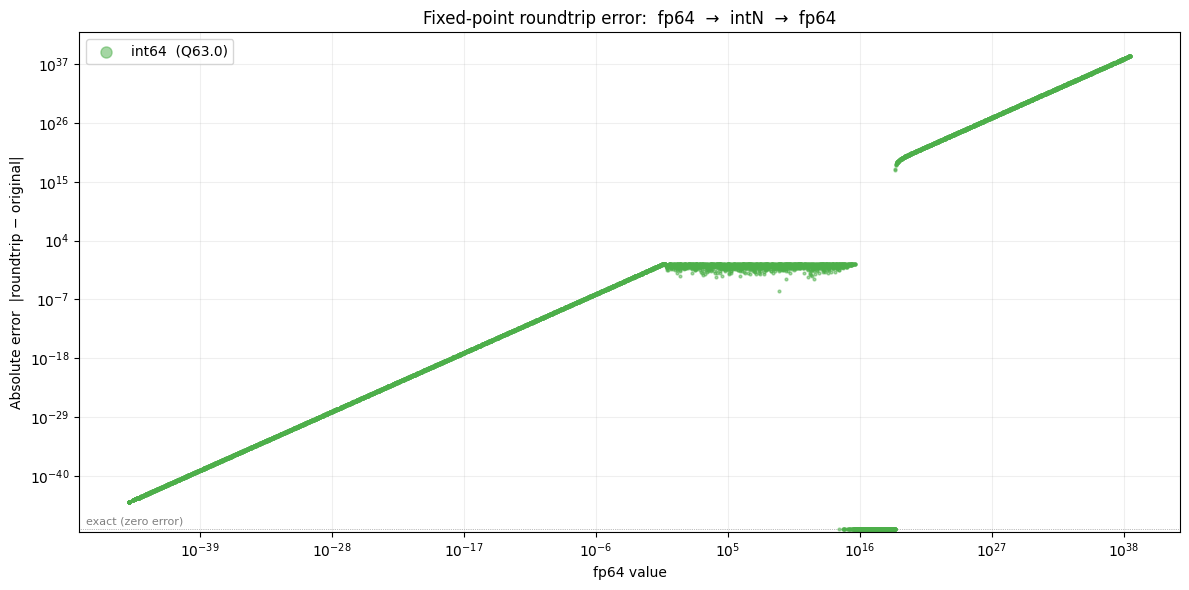

In [36]:
plot_cast_error(torch.float64, [torch.int64])